# PHẦN 1: KHÁM PHÁ VÀ PHÂN TÍCH DỮ LIỆU (EDA)
**Bộ dữ liệu:** MS COCO 2014 (Phiên bản phân chia theo chuẩn Karpathy)
**Mục tiêu:** 
1. Hiểu rõ cấu trúc file dữ liệu gốc (`dataset_coco.json`).
2. Trực quan hóa hình ảnh và các câu chú thích (Captions) tương ứng.
3. Thống kê phân phối độ dài câu và tần suất từ vựng nhằm đưa ra cơ sở thiết lập tham số cho kiến trúc Encoder-Decoder.

In [1]:
import os
import json
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from collections import Counter

# Thiết lập đường dẫn tĩnh
DATA_FOLDER = '../data/coco/'
KARPATHY_JSON_PATH = os.path.join(DATA_FOLDER, 'caption_datasets', 'dataset_coco.json')

print("Đã nạp xong thư viện!")

Đã nạp xong thư viện!


## 1. Phân bổ dữ liệu (Data Splits)
Theo chuẩn nghiên cứu quốc tế, đồ án sử dụng bộ chia dữ liệu của Karpathy et al., chia lại tập MS COCO 2014 thành 3 tập: Train, Val, và Test.

Tổng số bức ảnh: 123,287
Tổng số câu chú thích: 616,767

Phân bổ tập dữ liệu (Karpathy Split):
- Tập TEST: 5,000 ảnh (4.1%)
- Tập RESTVAL: 30,504 ảnh (24.7%)
- Tập VAL: 5,000 ảnh (4.1%)
- Tập TRAIN: 82,783 ảnh (67.1%)


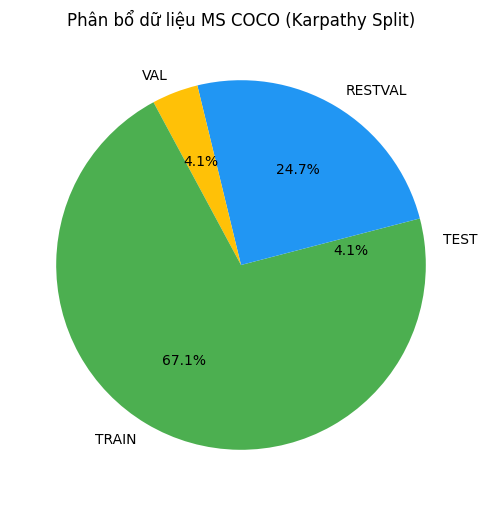

In [2]:
# Tải file JSON
with open(KARPATHY_JSON_PATH, 'r') as j:
    data = json.load(j)

# Thống kê số lượng
split_counts = Counter([img['split'] for img in data['images']])
total_images = len(data['images'])
total_captions = sum([len(img['sentences']) for img in data['images']])

print(f"Tổng số bức ảnh: {total_images:,}")
print(f"Tổng số câu chú thích: {total_captions:,}\n")
print("Phân bổ tập dữ liệu (Karpathy Split):")
for split, count in split_counts.items():
    print(f"- Tập {split.upper()}: {count:,} ảnh ({count/total_images*100:.1f}%)")
    
# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(split_counts.values(), labels=[s.upper() for s in split_counts.keys()], autopct='%1.1f%%', colors=['#4CAF50', '#2196F3', '#FFC107'])
plt.title('Phân bổ dữ liệu MS COCO (Karpathy Split)')
plt.show()

## 2. Trực quan hóa Ảnh và Chú thích (Captions)
Mỗi bức ảnh trong bộ COCO đi kèm với 5 câu chú thích do con người (Human Annotators) miêu tả. Điều này giúp mô hình học được nhiều góc nhìn và cấu trúc ngữ pháp khác nhau cho cùng một khung cảnh.

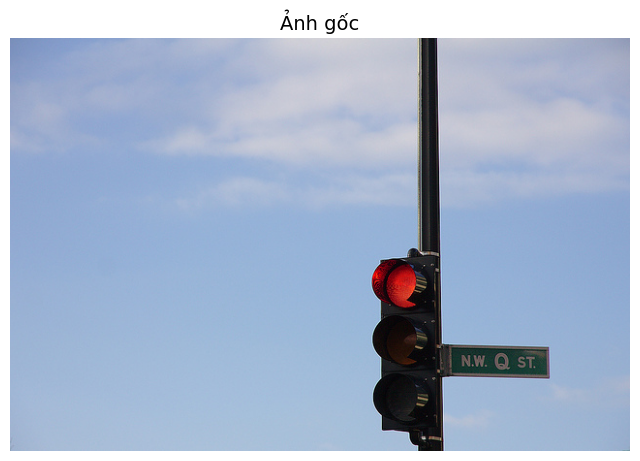

📝 5 câu chú thích (Human Annotations):
  1. a light that is attached to a pole
  2. A red traffic light sitting next to a street sign.
  3. A stop light with a street sign next to it.
  4. A traffic light and a street sign are mounted to a pole.
  5. A traffic signal is pictured against a blue sky.


In [3]:
# Lấy ngẫu nhiên 1 ảnh từ tập Train
train_images = [img for img in data['images'] if img['split'] == 'train']
sample_img = random.choice(train_images)

# Xác định đường dẫn ảnh vật lý (train2014 hoặc val2014)
folder_name = sample_img['filepath'] 
img_path = os.path.join(DATA_FOLDER, folder_name, sample_img['filename'])

# Hiển thị
try:
    img = Image.open(img_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Ảnh gốc", fontsize=14)
    plt.show()

    print("📝 5 câu chú thích (Human Annotations):")
    for i, sentence in enumerate(sample_img['sentences']):
        print(f"  {i+1}. {sentence['raw']}")
except FileNotFoundError:
    print(f"❌ Không tìm thấy ảnh tại: {img_path}. Vui lòng kiểm tra lại đường dẫn giải nén!")

## 3. Phân tích phân phối Ngôn ngữ (Linguistic Distribution)
Để thiết kế ma trận đầu vào (Embedding) và chuỗi thời gian cho mạng LSTM, chúng ta cần phân tích chiều dài trung bình của câu và loại bỏ các từ quá hiếm gặp (Nhiễu/Noise).

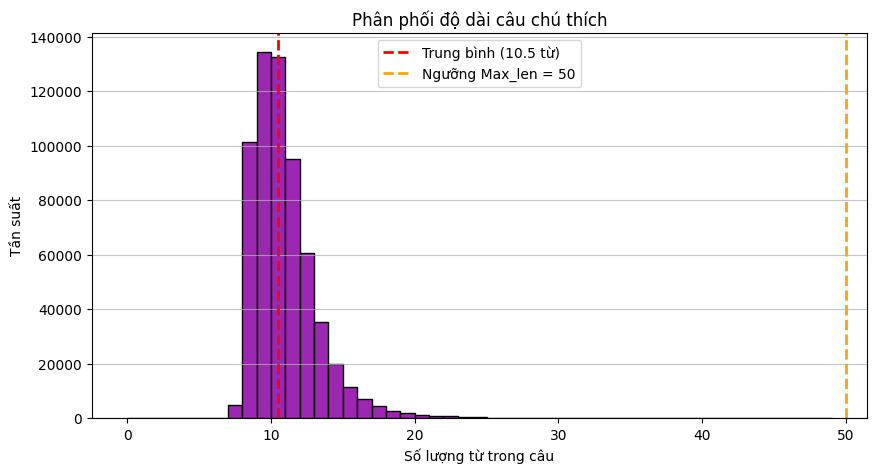

Tổng số từ vựng duy nhất (Raw Vocab): 27,929 từ
Số lượng từ xuất hiện >= 5 lần: 10,368 từ
👉 Kết luận: Việc thiết lập ngưỡng min_word_freq=5 giúp giảm 62.9% kích thước ma trận Embedding, tối ưu hóa bộ nhớ mà không làm mất đi các từ mang nghĩa biểu đạt chính.


In [4]:
all_lengths = []
all_words = []

for img in data['images']:
    for sentence in img['sentences']:
        tokens = sentence['tokens']
        all_lengths.append(len(tokens))
        all_words.extend(tokens)

# 1. Vẽ biểu đồ phân phối độ dài câu
plt.figure(figsize=(10, 5))
plt.hist(all_lengths, bins=range(0, max(all_lengths)+1), color='#9C27B0', edgecolor='black')
plt.axvline(np.mean(all_lengths), color='red', linestyle='dashed', linewidth=2, label=f'Trung bình ({np.mean(all_lengths):.1f} từ)')
plt.axvline(50, color='orange', linestyle='dashed', linewidth=2, label='Ngưỡng Max_len = 50')
plt.title('Phân phối độ dài câu chú thích')
plt.xlabel('Số lượng từ trong câu')
plt.ylabel('Tần suất')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Phân tích từ vựng
word_counts = Counter(all_words)
total_unique_words = len(word_counts)
words_above_threshold = len([w for w, c in word_counts.items() if c >= 5])

print(f"Tổng số từ vựng duy nhất (Raw Vocab): {total_unique_words:,} từ")
print(f"Số lượng từ xuất hiện >= 5 lần: {words_above_threshold:,} từ")
print(f"👉 Kết luận: Việc thiết lập ngưỡng min_word_freq=5 giúp giảm {(1 - words_above_threshold/total_unique_words)*100:.1f}% kích thước ma trận Embedding, tối ưu hóa bộ nhớ mà không làm mất đi các từ mang nghĩa biểu đạt chính.")